# 13. Autocodificador Variacional (VAE) con PyTorch

Esta sección presenta una alternativa **generativa** al clasificador de MNIST desarrollado anteriormente. Es completamente autónoma: puede ejecutarse desde un kernel recién iniciado y utiliza únicamente PyTorch dentro de este bloque.

## 13.1. Objetivos de aprendizaje

Al finalizar seremos capaces de:

- Explicar qué hacen el *encoder*, el espacio latente y el *decoder*.
- Distinguir un autocodificador determinista de un autocodificador variacional.
- Comprender el prior, el posterior aproximado, la ELBO y el truco de reparametrización.
- Implementar y entrenar un AE, un VAE denso y un VAE convolucional.
- Reconstruir imágenes, generar dígitos nuevos e interpretar el espacio latente.
- Diagnosticar problemas como el sobreajuste, una KL dominante o el *posterior collapse*.

> **Ejecución recomendada:** reiniciar el kernel y ejecutar desde esta sección. Así se evita que TensorFlow y PyTorch reserven simultáneamente memoria de la GPU.

## 13.2. ¿Qué es un autocodificador?

Un **autocodificador** aprende a reproducir su propia entrada. No necesita la etiqueta del dígito para entrenar: la imagen es simultáneamente la entrada y el objetivo.

$$
x \xrightarrow{\text{encoder}} z \xrightarrow{\text{decoder}} \hat{x}
$$

- $x$ es la imagen original.
- El **encoder** comprime $x$ en una representación latente $z$.
- El **decoder** intenta reconstruir la imagen como $\hat{x}$.
- La función de pérdida mide cuánto difieren $x$ y $\hat{x}$.

Si $z$ tiene mucha menos información que la imagen, la red no puede limitarse a copiar píxeles: debe aprender regularidades como trazos, inclinación y grosor. Sin embargo, un autocodificador convencional no impone una estructura probabilística a $z$. Por eso empezaremos con él como referencia y después introduciremos el VAE.

In [2]:
# Esta sección es autónoma: repetimos explícitamente todos sus imports.
# Copiamos estados de modelos y medimos tiempos durante el entrenamiento.
import copy
# Controlamos la aleatoriedad de Python, NumPy y PyTorch.
import random
import time
# Usamos rutas independientes del sistema para localizar los datos.
from pathlib import Path

# Librerías para representar resultados y curvas de aprendizaje.
import matplotlib.pyplot as plt
import numpy as np
# Componentes de PyTorch para tensores, redes y funciones de pérdida.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
# Utilidades para construir batches y cargar el conjunto MNIST.
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Hiperparámetros compartidos por el AE y los dos VAE.
SEED = 42
BATCH_SIZE = 128
LATENT_DIM = 16
AE_EPOCHS = 5
VAE_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
BETA_WARMUP_EPOCHS = 4

# Fijamos las semillas para obtener resultados aproximadamente reproducibles.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    # En GPU también fijamos la semilla de todos los dispositivos CUDA visibles.
    torch.cuda.manual_seed_all(SEED)

# Seleccionamos GPU cuando existe; en caso contrario usamos la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Guardamos el tipo de dispositivo para reutilizarlo en la configuración.
DEVICE_TYPE = device.type
# La memoria fijada acelera las transferencias CPU-GPU y solo se activa en CUDA.
PIN_MEMORY = DEVICE_TYPE == "cuda"
# Los datos se guardan en una carpeta relativa al directorio del notebook.
DATA_DIR = Path("./data")

# Mostramos la configuración efectiva para detectar problemas del entorno al principio.
print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo seleccionado: {device}")
if DEVICE_TYPE == "cuda":
    # En instalaciones AMD/ROCm PyTorch conserva el nombre histórico de la API CUDA.
    print(f"Acelerador: {torch.cuda.get_device_name(0)}")
print(f"Semilla: {SEED}")

PyTorch: 2.14.0.dev20260712+rocm7.2
Dispositivo seleccionado: cuda
Acelerador: AMD Radeon RX 9070 XT
Semilla: 42


## 13.3. Preparación autónoma de MNIST

Usaremos `torchvision.datasets.MNIST`, no los arrays de Keras de las secciones anteriores. `ToTensor()` realiza dos operaciones:

1. Cambia la disposición a `(canales, alto, ancho)`.
2. Convierte los enteros de $[0,255]$ a `float32` en $[0,1]$.

Conservamos ese rango porque interpretaremos cada salida como la probabilidad de que un píxel esté encendido. Separamos los 60 000 ejemplos oficiales de entrenamiento en **55 000 para entrenar** y **5 000 para validar**. Las 10 000 imágenes oficiales de test se reservan hasta el final: mirar test durante el diseño produciría fuga de información.

Aunque las etiquetas se conservan para visualizar el espacio latente, **no se usan en la pérdida**. El objetivo de cada imagen es ella misma.

In [3]:
# ToTensor convierte las imágenes a float32 con forma (canal, alto, ancho) y rango [0, 1].
transform = transforms.ToTensor()

# Cargamos las 60 000 imágenes oficiales de entrenamiento de MNIST.
full_train_dataset = datasets.MNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
# Cargamos aparte las 10 000 imágenes de test para reservarlas hasta la evaluación final.
test_dataset = datasets.MNIST(
    root=DATA_DIR, train=False, download=True, transform=transform
)

# Este generador hace reproducible la división entre entrenamiento y validación.
split_generator = torch.Generator().manual_seed(SEED)
# Usamos 55 000 imágenes para ajustar pesos y 5 000 para seleccionar el mejor estado.
train_dataset, val_dataset = random_split(
    full_train_dataset, [55_000, 5_000], generator=split_generator
)

# Un generador independiente hace reproducible el barajado del entrenamiento.
loader_generator = torch.Generator().manual_seed(SEED)
# Centralizamos opciones comunes para que los tres loaders tengan el mismo batch y dispositivo.
loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,  # La opción más estable dentro de Jupyter.
    "pin_memory": PIN_MEMORY,
}
# Solo el loader de entrenamiento baraja; validación y test conservan un orden estable.
train_loader = DataLoader(
    train_dataset, shuffle=True, generator=loader_generator, **loader_options
)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

# Tomamos un batch para inspeccionar desde el principio formas, etiquetas y rango de valores.
sample_images, sample_labels = next(iter(train_loader))
# Los asserts convierten las suposiciones sobre el dataset en comprobaciones ejecutables.
assert len(train_dataset) == 55_000
assert len(val_dataset) == 5_000
assert len(test_dataset) == 10_000
assert sample_images.shape[1:] == (1, 28, 28)
assert sample_images.dtype == torch.float32
assert 0.0 <= sample_images.min() and sample_images.max() <= 1.0

# Resumimos la configuración observada para poder detectar una carga incorrecta de MNIST.
print(f"Train/validación/test: {len(train_dataset):,}/{len(val_dataset):,}/{len(test_dataset):,}")
print(f"Forma de un batch: {tuple(sample_images.shape)}")
print(f"Etiquetas del batch: {tuple(sample_labels.shape)} (solo para interpretar resultados)")
print(f"Rango de píxeles: [{sample_images.min():.1f}, {sample_images.max():.1f}]")

Train/validación/test: 55,000/5,000/10,000
Forma de un batch: (128, 1, 28, 28)
Etiquetas del batch: (128,) (solo para interpretar resultados)
Rango de píxeles: [0.0, 1.0]


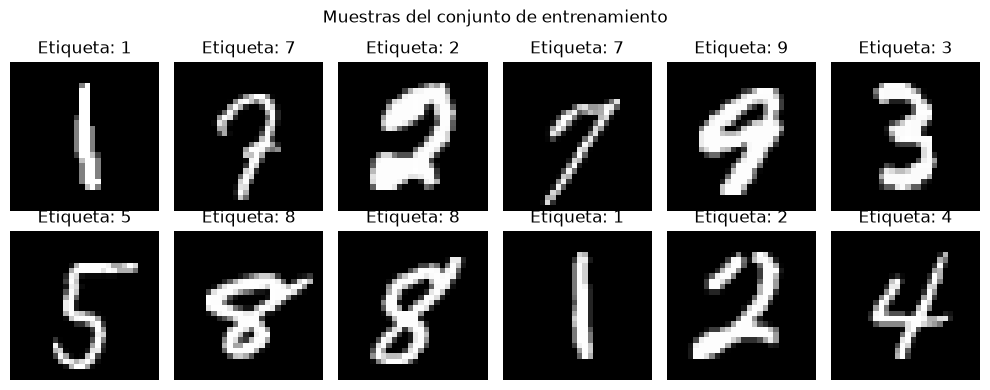

In [4]:
# Creamos una cuadrícula para comprobar visualmente el formato y el rango de las imágenes.
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
# Dibujamos doce ejemplos junto con su etiqueta, que aquí solo sirve para inspección.
for axis, image, label in zip(axes.flat, sample_images[:12], sample_labels[:12]):
    # Eliminamos el eje del canal para que matplotlib reciba una matriz 28 x 28.
    axis.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axis.set_title(f"Etiqueta: {label.item()}")
    axis.axis("off")
# Ajustamos el título y el espacio de la figura antes de mostrarla.
plt.suptitle("Muestras del conjunto de entrenamiento")
plt.tight_layout()
plt.show()

## 13.4. Nivel 1: autocodificador determinista

Nuestro primer modelo aplana cada imagen de $28\times28=784$ píxeles y la comprime hasta `LATENT_DIM` valores:

$$
784 \longrightarrow 256 \longrightarrow z \longrightarrow 256 \longrightarrow 784
$$

La capa final devuelve **logits**, valores reales sin restringir. Para comparar esos logits con píxeles en $[0,1]$ utilizaremos `binary_cross_entropy_with_logits`. Esta función combina internamente una sigmoide y la entropía cruzada binaria de manera numéricamente estable:

$$
\mathcal{L}_{rec}(x,\hat{x})
= -\sum_{i=1}^{784}\left[x_i\log(\hat{x}_i)+(1-x_i)\log(1-\hat{x}_i)\right].
$$

MNIST no es estrictamente binario porque contiene grises debidos al suavizado de bordes. Aun así, la BCE puede interpretarse como el error de probabilidades de activación de los píxeles. Otra posibilidad sería MSE; más adelante discutiremos la diferencia.

La sigmoide se aplica explícitamente **solo al visualizar**. Aplicarla en el modelo y usar después `binary_cross_entropy_with_logits` supondría aplicarla dos veces.

In [5]:
# El AE denso aprende una compresión 784 -> 256 -> LATENT_DIM y su expansión simétrica.
class DenseAutoencoder(nn.Module):
    """Autocodificador denso determinista para imágenes MNIST."""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # El encoder transforma cada imagen en un vector latente compacto.
        self.encoder = nn.Sequential(
            # Convertimos (batch, 1, 28, 28) en (batch, 784) antes de usar capas densas.
            nn.Flatten(),
            # La capa intermedia aprende combinaciones no lineales de los píxeles.
            nn.Linear(28 * 28, 256),
            # ReLU permite aprender relaciones no lineales sin cambiar la forma del tensor.
            nn.ReLU(),
            # El cuello de botella conserva solo LATENT_DIM valores por imagen.
            nn.Linear(256, latent_dim),
        )
        # El decoder intenta recuperar los 784 píxeles a partir del vector latente.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
        )

    def encode(self, images):
        # Codificar solo aplica el encoder y devuelve la representación latente.
        return self.encoder(images)

    def decode(self, latent_vectors):
        # El decoder devuelve logits: valores sin sigmoide para la BCE estable.
        logits = self.decoder(latent_vectors)
        # Reorganizamos (batch, 784) como imágenes (batch, 1, 28, 28).
        return logits.view(-1, 1, 28, 28)

    def forward(self, images):
        # El forward encadena compresión y reconstrucción para una entrada completa.
        return self.decode(self.encode(images))


def count_trainable_parameters(model):
    # Sumamos únicamente los parámetros que el optimizador puede actualizar.
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


# Instanciamos el AE y trasladamos sus parámetros al dispositivo elegido.
ae_model = DenseAutoencoder().to(device)
# La prueba de humo verifica formas y valores antes de iniciar el entrenamiento.
with torch.no_grad():
    ae_smoke_output = ae_model(sample_images[:4].to(device))

# La salida debe conservar la forma de las cuatro imágenes de entrada y ser finita.
assert ae_smoke_output.shape == sample_images[:4].shape
assert torch.isfinite(ae_smoke_output).all()
# Mostramos arquitectura, tamaño y transformación observada en la prueba.
print(ae_model)
print(f"Parámetros entrenables: {count_trainable_parameters(ae_model):,}")
print(f"Prueba de formas: {tuple(sample_images[:4].shape)} -> {tuple(ae_smoke_output.shape)}")

DenseAutoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
  )
)
Parámetros entrenables: 410,912
Prueba de formas: (4, 1, 28, 28) -> (4, 1, 28, 28)


In [6]:
def run_autoencoder_epoch(model, loader, optimizer=None):
    """Ejecuta una época y devuelve BCE media por imagen."""
    # Si hay optimizador estamos entrenando; sin él solo evaluamos.
    is_training = optimizer is not None
    # train(False) equivale a eval() para este modelo y deja clara la intención del modo.
    model.train(is_training)
    # Acumularemos la BCE de todas las imágenes, no la media de medias de los batches.
    total_reconstruction = 0.0

    # Solo construimos el grafo de gradientes cuando se actualizarán los pesos.
    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        # Las etiquetas se ignoran porque el objetivo del AE es reconstruir la imagen.
        for images, _ in loader:
            # Movemos cada batch al mismo dispositivo que el modelo.
            images = images.to(device, non_blocking=PIN_MEMORY)
            if is_training:
                # Borramos gradientes acumulados antes de calcular los del batch actual.
                optimizer.zero_grad(set_to_none=True)

            # El modelo produce logits con la misma forma que las imágenes originales.
            reconstruction_logits = model(images)
            # reduction="sum" conserva la suma sobre píxeles y ejemplos del batch.
            loss_sum = F.binary_cross_entropy_with_logits(
                reconstruction_logits, images, reduction="sum"
            )

            if is_training:
                # Promediar el batch estabiliza la magnitud de los gradientes.
                (loss_sum / images.size(0)).backward()
                # Adam aplica la actualización usando los gradientes recién calculados.
                optimizer.step()

            # item() pasa la métrica a Python para poder acumularla sin conservar el grafo.
            total_reconstruction += loss_sum.item()

    # Dividimos por el total de imágenes para obtener BCE media por imagen.
    return total_reconstruction / len(loader.dataset)


def fit_autoencoder(model, train_data, val_data, epochs=AE_EPOCHS):
    # Adam optimiza todos los parámetros entrenables del AE.
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # Guardamos por separado las curvas de entrenamiento y validación.
    history = {"train_loss": [], "val_loss": []}
    # Conservamos un estado inicial por si ninguna época mejora la validación.
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    # Medimos el tiempo solo alrededor del entrenamiento efectivo.
    start_time = time.perf_counter()

    # Cada iteración actualiza pesos con train y mide generalización con validación.
    for epoch in range(1, epochs + 1):
        train_loss = run_autoencoder_epoch(model, train_data, optimizer)
        val_loss = run_autoencoder_epoch(model, val_data)
        # Añadimos las métricas para graficar la evolución completa después.
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            # Una mejora de validación convierte el estado actual en el candidato elegido.
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        # Mostramos ambas métricas en la misma escala: BCE por imagen.
        print(
            f"AE | época {epoch:02d}/{epochs} | "
            f"train BCE: {train_loss:.2f} | val BCE: {val_loss:.2f}"
        )

    # Restauramos los pesos de la mejor época antes de devolver el historial.
    model.load_state_dict(best_state)
    history["seconds"] = time.perf_counter() - start_time
    history["best_val_loss"] = best_val_loss
    return history


def show_reconstructions(model, loader, title, count=10):
    # Ponemos el modelo en modo evaluación y no necesitamos gradientes para dibujar.
    model.eval()
    # Tomamos un único batch y limitamos la muestra al número solicitado.
    images, _ = next(iter(loader))
    images = images[:count].to(device)
    with torch.no_grad():
        # Admitimos tanto la salida simple del AE como la tupla devuelta por un VAE.
        output = model(images)
        logits = output[0] if isinstance(output, tuple) else output
        # Convertimos logits a probabilidades de píxel solo para visualizarlas.
        reconstructions = torch.sigmoid(logits)

    # Cada columna compara una imagen original con su reconstrucción.
    fig, axes = plt.subplots(2, count, figsize=(1.45 * count, 3.2))
    for index in range(count):
        # Movemos los tensores a CPU y quitamos dimensiones unitarias para matplotlib.
        axes[0, index].imshow(images[index].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, index].imshow(reconstructions[index].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, index].axis("off")
        axes[1, index].axis("off")
    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Reconstrucción")
    fig.suptitle(title)
    # Ajustamos márgenes y mostramos la comparación ya etiquetada.
    plt.tight_layout()
    plt.show()

AE | época 01/5 | train BCE: 145.68 | val BCE: 102.60
AE | época 02/5 | train BCE: 94.02 | val BCE: 89.36
AE | época 03/5 | train BCE: 86.46 | val BCE: 85.28
AE | época 04/5 | train BCE: 83.23 | val BCE: 82.79
AE | época 05/5 | train BCE: 81.14 | val BCE: 80.99
Mejor BCE de validación: 80.99
Tiempo de entrenamiento: 323.9 s


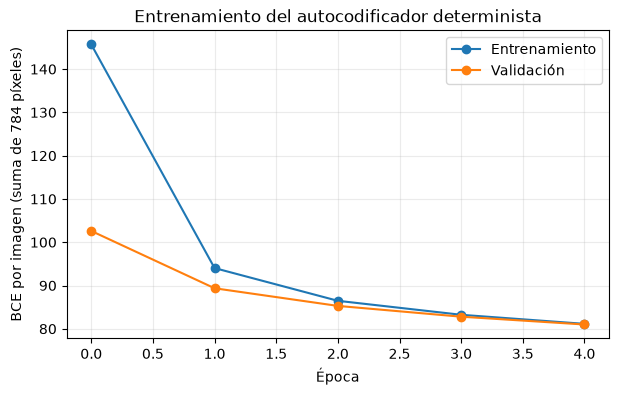

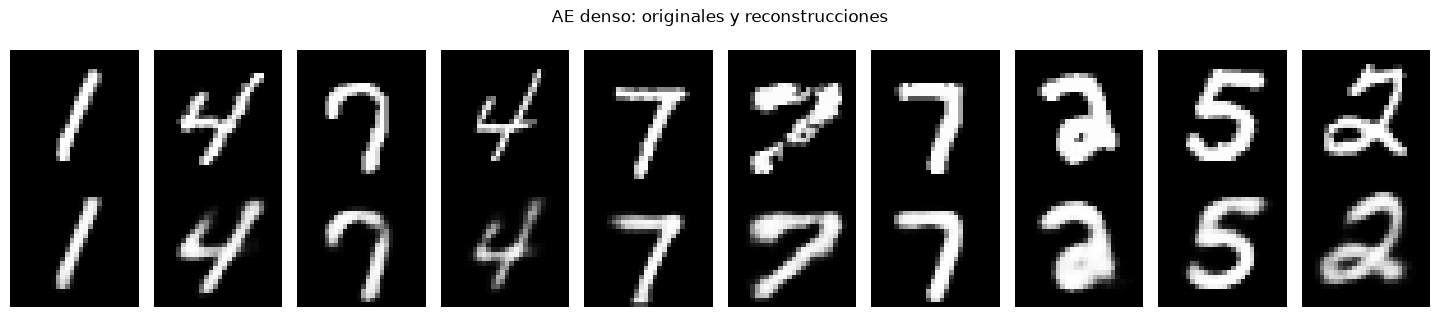

In [7]:
# Entrenamos el AE y conservamos sus métricas para comparar las dos curvas.
ae_history = fit_autoencoder(ae_model, train_loader, val_loader)
# Informamos el mejor resultado de validación y el coste temporal del ajuste.
print(f"Mejor BCE de validación: {ae_history['best_val_loss']:.2f}")
print(f"Tiempo de entrenamiento: {ae_history['seconds']:.1f} s")

# Graficamos train y validación para detectar convergencia o sobreajuste.
plt.figure(figsize=(7, 4))
plt.plot(ae_history["train_loss"], marker="o", label="Entrenamiento")
plt.plot(ae_history["val_loss"], marker="o", label="Validación")
plt.xlabel("Época")
plt.ylabel("BCE por imagen (suma de 784 píxeles)")
plt.title("Entrenamiento del autocodificador determinista")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Comparamos visualmente entradas y reconstrucciones del mejor estado del AE.
show_reconstructions(ae_model, val_loader, "AE denso: originales y reconstrucciones")

## 13.5. Del AE al VAE: una representación probabilística

El AE anterior asigna a cada imagen un único punto $z=f(x)$. Nada obliga a que los puntos ocupen una región continua ni a que los huecos entre ellos produzcan imágenes coherentes. Si elegimos un vector aleatorio, el decoder probablemente recibirá algo que nunca vio al entrenar.

El **Variational Autoencoder** sustituye ese punto por una distribución. El encoder aproxima el posterior desconocido mediante una normal:

$$
q_{\phi}(z\mid x)=\mathcal{N}\left(z;\mu(x),\operatorname{diag}(\sigma^2(x))\right).
$$

Por cada imagen predice dos vectores:

- `mu`: centro de la distribución latente.
- `logvar`: logaritmo de la varianza, $\log(\sigma^2)$.

Predecir `logvar` permite producir cualquier varianza positiva usando una exponencial y suele ser más estable que optimizar $\sigma$ directamente. El decoder modela $p_{\theta}(x\mid z)$ y se fija un prior sencillo:

$$
p(z)=\mathcal{N}(0,I).
$$

### La ELBO

La log-verosimilitud exacta requiere integrar todos los posibles $z$, algo intratable en una red. En su lugar maximizamos una cota inferior llamada **Evidence Lower BOund**. Como los optimizadores minimizan, usamos su versión negativa:

$$
\mathcal{L}_{VAE}
=
\underbrace{\mathcal{L}_{rec}(x,\hat{x})}_{\text{fidelidad}}
+
\beta\underbrace{D_{KL}\left(q_{\phi}(z\mid x)\;\|\;p(z)\right)}_{\text{regularidad del espacio latente}}.
$$

Para normales diagonales, la KL tiene solución cerrada:

$$
D_{KL}=-\frac{1}{2}\sum_j\left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\right).
$$

- La **reconstrucción** quiere conservar toda la información de cada imagen.
- La **KL** aproxima cada posterior al prior normal y hace que el espacio sea continuo y muestreable.
- $\beta=0$ elimina temporalmente la regularización; $\beta=1$ corresponde al VAE estándar; $\beta>1$ prioriza una representación más regular, normalmente a costa de detalle.

Durante las primeras épocas calentaremos $\beta$ de forma lineal hasta 1. Esto permite aprender primero una señal de reconstrucción útil y reduce el riesgo de **posterior collapse**, situación en la que $q(z\mid x)$ se parece al prior para todas las imágenes y $z$ deja de transportar información.

### El truco de reparametrización

No podemos retropropagar de manera directa a través de la operación «muestrear de una normal cuyos parámetros produce la red». Separamos por ello el azar de los parámetros aprendidos:

$$
\epsilon\sim\mathcal{N}(0,I),\qquad
z=\mu+\sigma\odot\epsilon
=\mu+\exp\left(\frac{1}{2}\log\sigma^2\right)\odot\epsilon.
$$

Ahora la fuente aleatoria $\epsilon$ no depende del encoder, mientras que $z$ sí es una función diferenciable de $\mu$ y `logvar`. Esta transformación es el **truco de reparametrización**.

| Etapa | Forma para un batch de tamaño $N$ |
|---|---:|
| Imagen | `(N, 1, 28, 28)` |
| Imagen aplanada | `(N, 784)` |
| Representación oculta | `(N, 128)` |
| `mu` y `logvar` | `(N, LATENT_DIM)` cada una |
| Muestra $z$ | `(N, LATENT_DIM)` |
| Logits reconstruidos | `(N, 1, 28, 28)` |

Durante el entrenamiento se muestrea $z$. Para comparar reconstrucciones de forma estable usaremos $z=\mu$; esto representa el centro del posterior y evita que una visualización cambie por azar.

In [ ]:
# El VAE denso representa cada imagen mediante una distribución latente, no mediante un único punto.
class DenseVAE(nn.Module):
    """VAE denso con posterior normal diagonal."""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # Guardamos la dimensión para poder muestrear el prior en las funciones de visualización.
        # El prior es la distribución que suponemos para los vectores latentes antes de observar una imagen.
        self.latent_dim = latent_dim
        # El backbone comparte características antes de estimar media y varianza.
        self.encoder_backbone = nn.Sequential(
            # Aplanamos la imagen para procesarla con capas lineales.
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, 128),
            nn.ReLU(),
        )
        # Cada cabeza predice un parámetro del posterior normal diagonal q(z|x).
        self.mu_head = nn.Linear(128, latent_dim)
        self.logvar_head = nn.Linear(128, latent_dim)
        # El decoder transforma una muestra latente en 784 logits de píxel.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
        )

    def encode(self, images):
        # Extraemos características comunes y calculamos media y log-varianza por imagen.
        hidden = self.encoder_backbone(images)
        return self.mu_head(hidden), self.logvar_head(hidden)

    def reparameterize(self, mu, logvar):
        # logvar representa log(sigma^2); multiplicar por 0.5 produce log(sigma).
        standard_deviation = torch.exp(0.5 * logvar)
        # El ruido independiente permite muestrear sin romper la retropropagación hacia mu/logvar.
        epsilon = torch.randn_like(standard_deviation)
        return mu + standard_deviation * epsilon

    def decode(self, latent_vectors):
        # El decoder conserva logits porque la función de pérdida aplicará la sigmoide internamente.
        logits = self.decoder(latent_vectors)
        # Recuperamos la forma de imagen para que coincida con las entradas de MNIST.
        return logits.view(-1, 1, 28, 28)

    def forward(self, images):
        # El forward completo codifica, muestrea z y decodifica esa muestra.
        mu, logvar = self.encode(images)
        latent_vectors = self.reparameterize(mu, logvar)
        return self.decode(latent_vectors), mu, logvar


# Instanciamos el VAE denso en el mismo dispositivo que los datos.
dense_vae = DenseVAE().to(device)
# La prueba de humo comprueba simultáneamente la reconstrucción y los parámetros del posterior.
with torch.no_grad():
    dense_logits, dense_mu, dense_logvar = dense_vae(sample_images[:4].to(device))

# Verificamos las formas esperadas y que ningún tensor contenga NaN o infinito.
assert dense_logits.shape == sample_images[:4].shape
assert dense_mu.shape == dense_logvar.shape == (4, LATENT_DIM)
assert all(torch.isfinite(tensor).all() for tensor in (dense_logits, dense_mu, dense_logvar))
# Mostramos la arquitectura y las formas observadas en el smoke test.
print(dense_vae)
print(f"Parámetros entrenables: {count_trainable_parameters(dense_vae):,}")
print(f"mu/logvar: {tuple(dense_mu.shape)} | reconstrucción: {tuple(dense_logits.shape)}")

DenseVAE(
  (encoder_backbone): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=400, bias=True)
    (2): ReLU()
    (3): Linear(in_features=400, out_features=128, bias=True)
    (4): ReLU()
  )
  (mu_head): Linear(in_features=128, out_features=16, bias=True)
  (logvar_head): Linear(in_features=128, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=784, bias=True)
  )
)
Parámetros entrenables: 737,616
mu/logvar: (4, 16) | reconstrucción: (4, 1, 28, 28)


### Cabeza

Una cabeza (head) es una capa de salida especializada que parte de una representación compartida.

En este VAE, encoder_backbone produce 128 características. Después se bifurca en dos cabezas:


mu_head aprende a calcular 
𝜇
μ.
logvar_head aprende a calcular 
log
⁡
(
𝜎
2
)
log(σ 
2
 ).
Ambas reciben las mismas 128 características, pero tienen pesos diferentes y realizan predicciones distintas. No es un concepto exclusivo de los VAE: se utiliza en cualquier red con varias salidas especializadas.

### Reparametrizacion

`reparameterize` convierte los **32 parámetros** producidos por el encoder (`16 mu` + `16 logvar`) en **una muestra latente `z` de 16 valores** que puede recibir el decoder.

```python
def reparameterize(self, mu, logvar):
    standard_deviation = torch.exp(0.5 * logvar)
    epsilon = torch.randn_like(standard_deviation)
    return mu + standard_deviation * epsilon
```

**Qué hace paso a paso**

1. El encoder genera:
   - `mu`: 16 medias.
   - `logvar`: 16 **log-varianzas**, no desviaciones estándar.

2. Recupera la desviación estándar:

$$
\sigma=\exp\left(\frac{1}{2}\log(\sigma^2)\right)
$$

3. Genera 16 números aleatorios estándar:

$$
\epsilon\sim\mathcal N(0,I)
$$

4. Desplaza y escala esos números:

$$
z=\mu+\sigma\odot\epsilon
$$

Así, cada componente queda:

$$
z_j=\mu_j+\sigma_j\epsilon_j
$$

Por ejemplo, si $\mu_j=3$, $\sigma_j=0.5$ y $\epsilon_j=-0.4$:

$$
z_j=3+0.5(-0.4)=2.8
$$

**¿Por qué es necesario?**

Queremos muestrear:

$$
z\sim\mathcal N(\mu,\sigma^2)
$$

pero una operación de muestreo directo introduce azar en medio del grafo y dificulta calcular cómo cambia el resultado respecto a `mu` y `logvar`.

La reparametrización mueve el azar a `epsilon`, que no depende de la red. Una vez fijado ese `epsilon`, `z` es una combinación diferenciable:

```text
mu ───────────────┐
                  ├──> z ──> decoder ──> pérdida
logvar -> sigma ──┤
epsilon aleatorio ┘
```

Esto permite que `loss.backward()` envíe gradientes hacia ambas cabezas del encoder y aprenda tanto:

- **Dónde situar la distribución** mediante `mu`.
- **Cuánta incertidumbre permitir** mediante `logvar`.

**Dimensiones**

Para un batch de 128 imágenes:

```text
mu       (128, 16)
logvar   (128, 16)
epsilon  (128, 16)
z        (128, 16)
```

Los 32 valores no se concatenan. Describen 16 distribuciones normales, y de cada una se obtiene una muestra. El decoder recibe únicamente los **16 valores de `z`**.

En resumen: el objetivo de `reparameterize` es **muestrear un vector latente aleatorio sin impedir que el VAE pueda entrenarse mediante retropropagación**.

In [8]:
def vae_loss(reconstruction_logits, images, mu, logvar, beta=1.0):
    """Devuelve objetivo beta-VAE, reconstrucción y KL como sumas del batch."""
    # La BCE compara logits con píxeles en [0, 1] y aplica la sigmoide de forma estable.
    reconstruction = F.binary_cross_entropy_with_logits(
        reconstruction_logits, images, reduction="sum"
    )
    # Esta es la KL cerrada entre N(mu, diag(sigma^2)) y el prior N(0, I).
    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    # beta controla cuánto pesa la regularización frente a la fidelidad de reconstrucción.
    objective = reconstruction + beta * kl_divergence
    # Devolvemos el total y sus componentes para entrenar y diagnosticar por separado.
    return objective, reconstruction, kl_divergence


def run_vae_epoch(model, loader, beta=1.0, optimizer=None):
    # La presencia del optimizador distingue una época de entrenamiento de una de evaluación.
    is_training = optimizer is not None
    # train(False) activa el comportamiento de evaluación del modelo.
    model.train(is_training)
    # Acumulamos cada componente como suma de imágenes para evitar sesgo del último batch.
    totals = {"loss": 0.0, "reconstruction": 0.0, "kl": 0.0}

    # El grafo de autograd solo se necesita cuando habrá una actualización de pesos.
    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        # Las etiquetas no intervienen: el VAE aprende a reconstruir cada imagen.
        for images, _ in loader:
            # El modelo y los datos deben residir en el mismo dispositivo.
            images = images.to(device, non_blocking=PIN_MEMORY)
            if is_training:
                # Eliminamos gradientes del batch anterior antes del forward actual.
                optimizer.zero_grad(set_to_none=True)

            # El forward devuelve logits reconstruidos y los parámetros del posterior.
            reconstruction_logits, mu, logvar = model(images)
            # Calculamos ELBO negativa y sus dos términos para poder inspeccionarlos.
            objective, reconstruction, kl_divergence = vae_loss(
                reconstruction_logits, images, mu, logvar, beta
            )

            # Detectamos inestabilidad numérica antes de propagarla a los parámetros.
            if not torch.isfinite(objective):
                raise RuntimeError("La pérdida dejó de ser finita; revise tasa de aprendizaje y datos.")

            if is_training:
                # La pérdida se divide por el tamaño real del batch para estabilizar gradientes.
                (objective / images.size(0)).backward()
                # Adam actualiza encoder y decoder con los gradientes calculados.
                optimizer.step()

            # Convertimos a escalares y acumulamos sin conservar el grafo de autograd.
            totals["loss"] += objective.item()
            totals["reconstruction"] += reconstruction.item()
            totals["kl"] += kl_divergence.item()

    # Todas las métricas quedan expresadas como promedio por imagen del dataset.
    return {name: value / len(loader.dataset) for name, value in totals.items()}


def fit_vae(model, train_data, val_data, model_name, max_epochs=VAE_EPOCHS):
    # Adam comparte la tasa de aprendizaje con el AE para facilitar la comparación.
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # El historial conserva total, reconstrucción, KL y beta para cada época.
    history = {
        "train_loss": [], "val_loss": [],
        "train_reconstruction": [], "val_reconstruction": [],
        "train_kl": [], "val_kl": [], "beta": [],
    }
    # Guardamos una copia independiente de los mejores parámetros observados.
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    # Este contador empieza a ser relevante cuando beta ya llegó a 1.
    epochs_without_improvement = 0
    # Medimos la duración del ajuste completo, incluido el posible early stopping.
    start_time = time.perf_counter()

    # Cada época aumenta gradualmente la presión de la regularización KL.
    for epoch in range(1, max_epochs + 1):
        beta = min(1.0, epoch / BETA_WARMUP_EPOCHS)
        # Durante train usamos el beta del warm-up para evitar una KL dominante al inicio.
        train_metrics = run_vae_epoch(model, train_data, beta=beta, optimizer=optimizer)
        # La validación siempre usa beta=1: así la métrica es comparable entre épocas.
        val_metrics = run_vae_epoch(model, val_data, beta=1.0)

        # Registramos beta y cada componente para analizarlos después.
        history["beta"].append(beta)
        for metric in ("loss", "reconstruction", "kl"):
            history[f"train_{metric}"].append(train_metrics[metric])
            history[f"val_{metric}"].append(val_metrics[metric])

        # Mostramos reconstrucción y KL además del objetivo total para diagnosticar el equilibrio.
        print(
            f"{model_name} | época {epoch:02d}/{max_epochs} | beta: {beta:.2f} | "
            f"train rec/KL: {train_metrics['reconstruction']:.2f}/{train_metrics['kl']:.2f} | "
            f"val rec/KL/ELBO-: {val_metrics['reconstruction']:.2f}/"
            f"{val_metrics['kl']:.2f}/{val_metrics['loss']:.2f}"
        )

        # Solo activamos early stopping una vez finalizado el calentamiento.
        if beta == 1.0:
            if val_metrics["loss"] < best_val_loss - 1e-3:
                # Copiamos el estado actual cuando la ELBO negativa mejora en validación.
                best_val_loss = val_metrics["loss"]
                best_state = copy.deepcopy(model.state_dict())
                epochs_without_improvement = 0
            else:
                # Contamos épocas consecutivas sin mejora significativa.
                epochs_without_improvement += 1
                if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                    print(f"Early stopping: {EARLY_STOPPING_PATIENCE} épocas sin mejora.")
                    break

    # Recuperamos los mejores pesos, aunque la última época no sea la mejor.
    model.load_state_dict(best_state)
    history["seconds"] = time.perf_counter() - start_time
    history["best_val_loss"] = best_val_loss
    # El número real puede ser menor que max_epochs si se activó early stopping.
    history["epochs_ran"] = len(history["val_loss"])
    return history


def plot_vae_history(history, title):
    # Usamos el número real de épocas para que el eje coincida con el historial.
    epochs = np.arange(1, history["epochs_ran"] + 1)
    # Separamos reconstrucción y KL para no ocultar sus escalas relativas.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_reconstruction"], marker="o", label="Rec. train")
    axes[0].plot(epochs, history["val_reconstruction"], marker="o", label="Rec. val")
    axes[0].set_title("Pérdida de reconstrucción")
    axes[1].plot(epochs, history["train_kl"], marker="o", label="KL train")
    axes[1].plot(epochs, history["val_kl"], marker="o", label="KL val")
    axes[1].set_title("Divergencia KL")
    for axis in axes:
        # Compartimos etiquetas, cuadrícula y leyenda para facilitar la lectura.
        axis.set_xlabel("Época")
        axis.set_ylabel("Pérdida por imagen")
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### Funcion de perdida

He confirmado el flujo exacto: el modelo genera logits, `mu` y `logvar`; `vae_loss` suma BCE y KL; después se divide por el tamaño real del batch únicamente para `backward`. Ahora detallo qué representa matemáticamente cada término y qué parámetros aprende.

## Idea principal

La pérdida del VAE responde simultáneamente a dos preguntas:

1. **¿La imagen reconstruida se parece a la original?** → pérdida de reconstrucción.
2. **¿La distribución latente está bien organizada?** → divergencia KL.

El código está en `varitional_autoencoder.ipynb:872-885`:

```python
def vae_loss(reconstruction_logits, images, mu, logvar, beta=1.0):
    reconstruction = F.binary_cross_entropy_with_logits(
        reconstruction_logits, images, reduction="sum"
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    objective = reconstruction + beta * kl_divergence
    return objective, reconstruction, kl_divergence
```

## 1. Forward pass

Para cada imagen $x$, el encoder produce:

$$
\mu(x),\qquad \log\sigma^2(x)
$$

Después se obtiene una muestra latente mediante:

$$
\epsilon\sim\mathcal N(0,I)
$$

$$
z=\mu+\sigma\odot\epsilon
$$

Finalmente, el decoder transforma $z$ en 784 logits:

$$
x\rightarrow(\mu,\log\sigma^2)\rightarrow z\rightarrow
\text{logits de reconstrucción}
$$

Con un batch de 128:

```text
images                  (128, 1, 28, 28)
mu                      (128, 16)
logvar                  (128, 16)
z                       (128, 16)
reconstruction_logits   (128, 1, 28, 28)
```

## 2. Pérdida de reconstrucción

```python
reconstruction = F.binary_cross_entropy_with_logits(
    reconstruction_logits, images, reduction="sum"
)
```

Para cada píxel se calcula:

$$
\operatorname{BCE}(x_i,l_i)
=
-\left[
x_i\log(\sigma(l_i))
+(1-x_i)\log(1-\sigma(l_i))
\right]
$$

Aquí:

- $x_i$ es el valor real del píxel, entre 0 y 1.
- $l_i$ es el logit producido por el decoder.
- $\sigma(l_i)$ convierte el logit en una probabilidad entre 0 y 1.

`binary_cross_entropy_with_logits` combina BCE y sigmoide internamente por estabilidad numérica. Por eso el decoder no aplica sigmoide.

Con `reduction="sum"` se suman todos los píxeles y todas las imágenes:

$$
\mathcal L_{\mathrm{rec}}
=
\sum_{n=1}^{B}\sum_{i=1}^{784}
\operatorname{BCE}(x_{n,i},l_{n,i})
$$

Este término obliga al encoder y al decoder a conservar la información necesaria para reconstruir cada dígito.

## 3. Divergencia KL

El encoder describe, para cada imagen, el posterior aproximado:

$$
q_\phi(z\mid x)
=
\mathcal N\left(\mu,\operatorname{diag}(\sigma^2)\right)
$$

Queremos que se mantenga cerca del prior:

$$
p(z)=\mathcal N(0,I)
$$

La distancia se mide mediante:

$$
D_{\mathrm{KL}}\left(q_\phi(z\mid x)\parallel p(z)\right)
=
\frac12\sum_{j=1}^{16}
\left(
\mu_j^2+\sigma_j^2-1-\log\sigma_j^2
\right)
$$

El código utiliza una expresión equivalente:

```python
-0.5 * torch.sum(
    1 + logvar - mu.pow(2) - logvar.exp()
)
```

Cada operación significa:

```text
mu.pow(2)     = μ²
logvar.exp()  = exp(log σ²) = σ²
```

La KL es mínima, e igual a cero, cuando:

$$
\mu=0,\qquad \sigma^2=1
$$

Es decir, cuando el posterior coincide exactamente con $\mathcal N(0,I)$.

Sin KL, cada imagen podría ocupar una región arbitraria y separada del espacio latente. Entonces muestrear vectores aleatorios produciría imágenes incoherentes.

## 4. Pérdida total

$$
\mathcal L_{\mathrm{VAE}}
=
\mathcal L_{\mathrm{rec}}
+
\beta D_{\mathrm{KL}}
$$

```python
objective = reconstruction + beta * kl_divergence
```

Existe una tensión:

- Reconstrucción quiere codificar mucha información concreta sobre cada imagen.
- KL quiere que las distribuciones se parezcan a $\mathcal N(0,I)$.
- $\beta$ controla el equilibrio.

Con $\beta=0$, el espacio no se regulariza. Con $\beta=1$, tenemos el VAE estándar. Un $\beta$ alto impone más regularidad, pero puede empeorar las reconstrucciones.

## 5. Relación con la ELBO

El objetivo teórico es maximizar:

$$
\operatorname{ELBO}
=
\mathbb E_{q_\phi(z\mid x)}
[\log p_\theta(x\mid z)]
-
D_{\mathrm{KL}}(q_\phi(z\mid x)\parallel p(z))
$$

Como PyTorch minimiza pérdidas, se minimiza su versión negativa:

$$
-\operatorname{ELBO}
=
\mathcal L_{\mathrm{rec}}+D_{\mathrm{KL}}
$$

La BCE representa el negativo de $\log p_\theta(x\mid z)$. La reconstrucción se estima usando una muestra reparametrizada de $z$; la KL se calcula exactamente mediante su fórmula cerrada.

## 6. Retropropagación

En `varitional_autoencoder.ipynb:908-922` ocurre:

```python
reconstruction_logits, mu, logvar = model(images)
objective, reconstruction, kl_divergence = vae_loss(...)
(objective / images.size(0)).backward()
optimizer.step()
```

Los gradientes recorren dos caminos:

```text
Reconstrucción → decoder → z → mu/logvar → encoder
KL ───────────────────────→ mu/logvar → encoder
```

Por tanto:

- El decoder aprende únicamente mediante reconstrucción.
- El encoder aprende mediante reconstrucción y KL.
- `mu_head` aprende dónde situar cada distribución.
- `logvar_head` aprende su dispersión.

La reparametrización permite que el gradiente de reconstrucción atraviese $z$ y llegue al encoder.

## 7. División por batch

La función devuelve sumas, pero antes de `backward` se divide:

```python
(objective / images.size(0)).backward()
```

Así se optimiza la pérdida media por imagen:

$$
\frac{\mathcal L_{\mathrm{rec}}+\beta\mathcal L_{\mathrm{KL}}}{B}
$$

No se divide entre 784 píxeles, por lo que las métricas representan una suma por imagen. Al terminar la época, las sumas de todos los batches se dividen entre el número total de imágenes en `varitional_autoencoder.ipynb:925-930`.

En resumen, el VAE aprende a **reconstruir bien usando vectores latentes que, al mismo tiempo, forman un espacio continuo y compatible con una normal estándar**.

Prueba de pérdida (4 imágenes) | reconstrucción: 2173.26 | KL: 0.18
VAE denso | época 01/10 | beta: 0.25 | train rec/KL: 167.19/17.62 | val rec/KL/ELBO-: 118.20/29.37/147.57
VAE denso | época 02/10 | beta: 0.50 | train rec/KL: 107.77/24.43 | val rec/KL/ELBO-: 100.04/25.78/125.82
VAE denso | época 03/10 | beta: 0.75 | train rec/KL: 96.69/22.87 | val rec/KL/ELBO-: 92.62/23.99/116.60
VAE denso | época 04/10 | beta: 1.00 | train rec/KL: 92.64/21.30 | val rec/KL/ELBO-: 91.32/21.04/112.35
VAE denso | época 05/10 | beta: 1.00 | train rec/KL: 89.43/21.55 | val rec/KL/ELBO-: 89.33/21.26/110.58
VAE denso | época 06/10 | beta: 1.00 | train rec/KL: 87.30/21.77 | val rec/KL/ELBO-: 87.12/21.42/108.54
VAE denso | época 07/10 | beta: 1.00 | train rec/KL: 85.88/21.91 | val rec/KL/ELBO-: 86.81/21.22/108.03
VAE denso | época 08/10 | beta: 1.00 | train rec/KL: 84.65/22.00 | val rec/KL/ELBO-: 84.65/22.11/106.76
VAE denso | época 09/10 | beta: 1.00 | train rec/KL: 83.68/22.11 | val rec/KL/ELBO-: 84.49/21.69

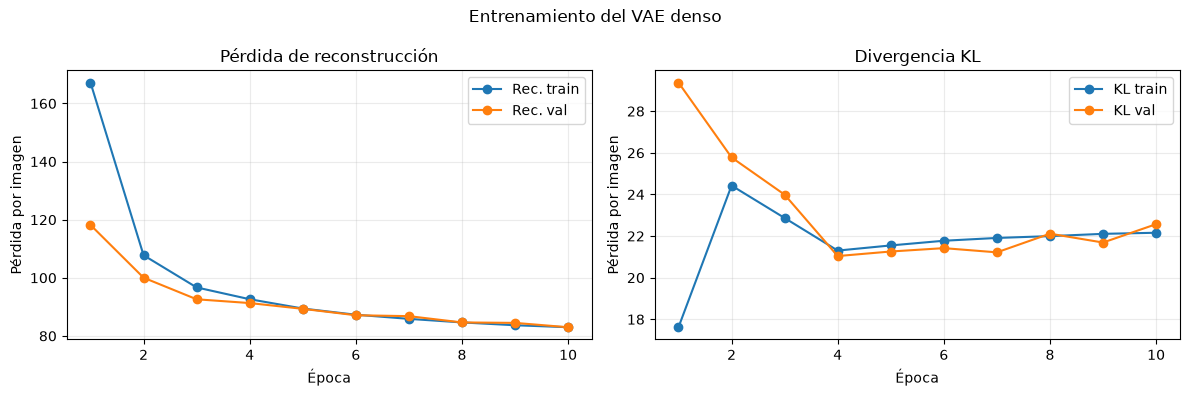

In [10]:
# Probamos la función de pérdida con cuatro ejemplos antes de iniciar el entrenamiento completo.
with torch.no_grad():
    smoke_objective, smoke_reconstruction, smoke_kl = vae_loss(
        dense_logits, sample_images[:4].to(device), dense_mu, dense_logvar
    )
# La pérdida total debe ser finita y la divergencia KL no puede ser negativa.
assert torch.isfinite(smoke_objective) and smoke_kl >= 0
# Mostramos los componentes para comprobar su escala inicial.
print(
    "Prueba de pérdida (4 imágenes) | "
    f"reconstrucción: {smoke_reconstruction.item():.2f} | KL: {smoke_kl.item():.2f}"
)

# Entrenamos el VAE denso con warm-up de beta y early stopping.
dense_vae_history = fit_vae(
    dense_vae, train_loader, val_loader, model_name="VAE denso"
)
# Informamos el mejor objetivo de validación y el tiempo empleado.
print(f"Mejor ELBO negativa de validación: {dense_vae_history['best_val_loss']:.2f}")
print(f"Tiempo: {dense_vae_history['seconds']:.1f} s")
# Separamos visualmente reconstrucción y KL para interpretar el compromiso del VAE.
plot_vae_history(dense_vae_history, "Entrenamiento del VAE denso")

In [11]:
def show_vae_reconstructions(model, loader, title, count=10):
    """Reconstruye con z=mu para obtener una comparación determinista."""
    # La evaluación desactiva comportamientos propios del entrenamiento.
    model.eval()
    # Seleccionamos un batch y limitamos el número de imágenes que se mostrarán.
    images, _ = next(iter(loader))
    images = images[:count].to(device)
    with torch.no_grad():
        # Usamos la media del posterior en lugar de volver a muestrear z con ruido.
        mu, _ = model.encode(images)
        # La sigmoide convierte los logits del decoder en intensidades de píxel.
        reconstructions = torch.sigmoid(model.decode(mu))

    # Cada columna enfrenta la imagen original con su reconstrucción determinista.
    fig, axes = plt.subplots(2, count, figsize=(1.45 * count, 3.2))
    for index in range(count):
        # CPU y squeeze dejan cada ejemplo en una matriz 28 x 28 para matplotlib.
        axes[0, index].imshow(images[index].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, index].imshow(reconstructions[index].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, index].axis("off")
        axes[1, index].axis("off")
    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("z = mu")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_generated_samples(model, title, count=16):
    """Genera imágenes nuevas muestreando el prior N(0, I)."""
    # El decoder recibe vectores que no proceden de ninguna imagen concreta.
    model.eval()
    with torch.no_grad():
        # Muestreamos directamente del prior normal aprendido como referencia del espacio latente.
        latent_vectors = torch.randn(count, model.latent_dim, device=device)
        # Convertimos los logits generados a probabilidades de píxel y los llevamos a CPU.
        generated = torch.sigmoid(model.decode(latent_vectors)).cpu()
    # Organizamos las imágenes en una cuadrícula para inspeccionar la calidad generativa.
    grid = make_grid(generated, nrow=4, padding=2, pad_value=1)
    plt.figure(figsize=(5, 5))
    # permute cambia de (canal, alto, ancho) a (alto, ancho, canal), formato de matplotlib.
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_latent_interpolation(model, loader, title, steps=12):
    """Decodifica el segmento que une las medias latentes de dos imágenes."""
    # Trabajamos en evaluación para que la secuencia solo dependa de los endpoints elegidos.
    model.eval()
    images, labels = next(iter(loader))
    # Las dos primeras imágenes definen los extremos de la trayectoria latente.
    endpoints = images[:2].to(device)
    with torch.no_grad():
        # Codificamos ambos extremos y usamos sus medias como puntos estables.
        mu, _ = model.encode(endpoints)
        # Creamos pesos equiespaciados entre 0 y 1 con forma compatible con el batch.
        weights = torch.linspace(0, 1, steps, device=device).unsqueeze(1)
        # Cada fila de trajectory es una combinación lineal entre las dos medias.
        trajectory = (1 - weights) * mu[0] + weights * mu[1]
        # Decodificamos todos los puntos y convertimos sus logits a intensidades visibles.
        decoded = torch.sigmoid(model.decode(trajectory)).cpu()

    # Dibujamos la transición completa y etiquetamos la posición relativa de cada punto.
    fig, axes = plt.subplots(1, steps, figsize=(1.3 * steps, 1.8))
    for index, (axis, image) in enumerate(zip(axes, decoded)):
        axis.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        axis.set_title(f"{index/(steps-1):.1f}")
        axis.axis("off")
    fig.suptitle(f"{title}: etiqueta {labels[0].item()} → {labels[1].item()}")
    plt.tight_layout()
    plt.show()


def plot_latent_pca(model, loader, title, max_samples=5_000):
    """Proyecta las medias latentes a 2D mediante PCA, solo para visualización."""
    # Inferimos medias latentes sin gradientes para analizar una muestra acotada del dataset.
    model.eval()
    latent_batches, label_batches = [], []
    collected = 0
    with torch.no_grad():
        for images, labels in loader:
            # El encoder trabaja en el dispositivo del modelo; las medias se guardan en CPU.
            mu, _ = model.encode(images.to(device))
            latent_batches.append(mu.cpu())
            # Las etiquetas solo se conservarán para colorear el gráfico al final.
            label_batches.append(labels)
            collected += images.size(0)
            # Limitamos el coste del análisis sin alterar el entrenamiento del VAE.
            if collected >= max_samples:
                break

    # Concatenamos batches y recortamos por si el último batch supera el límite solicitado.
    latent = torch.cat(latent_batches)[:max_samples]
    labels = torch.cat(label_batches)[:max_samples]
    # PCA requiere centrar las variables para analizar variaciones alrededor de su media.
    centered = latent - latent.mean(dim=0, keepdim=True)
    # Obtenemos las dos direcciones de mayor varianza del espacio latente.
    _, _, principal_directions = torch.pca_lowrank(centered, q=2)
    # Proyectamos cada vector de 16 dimensiones sobre esas dos direcciones principales.
    projection = centered @ principal_directions[:, :2]

    # El color usa etiquetas únicamente como ayuda visual posterior al entrenamiento.
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        projection[:, 0], projection[:, 1], c=labels,
        cmap="tab10", s=8, alpha=0.55
    )
    plt.colorbar(scatter, ticks=range(10), label="Dígito real (no usado al entrenar)")
    plt.xlabel("Componente principal 1")
    plt.ylabel("Componente principal 2")
    plt.title(title)
    plt.grid(alpha=0.15)
    plt.show()

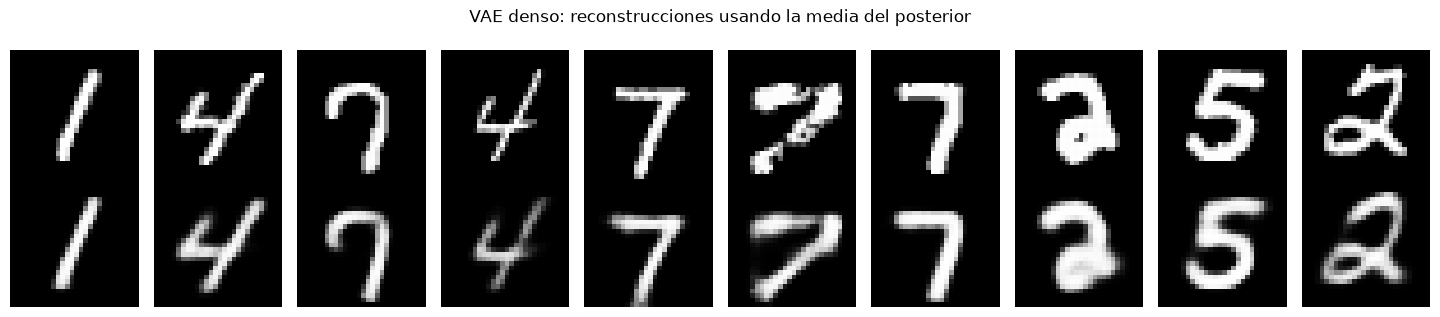

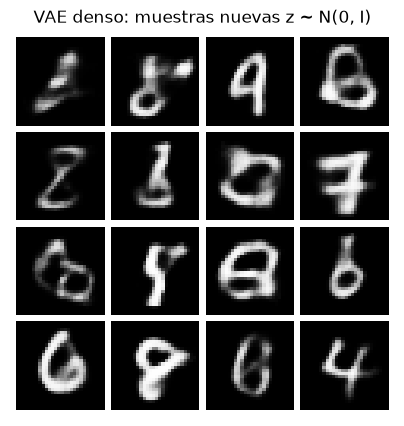

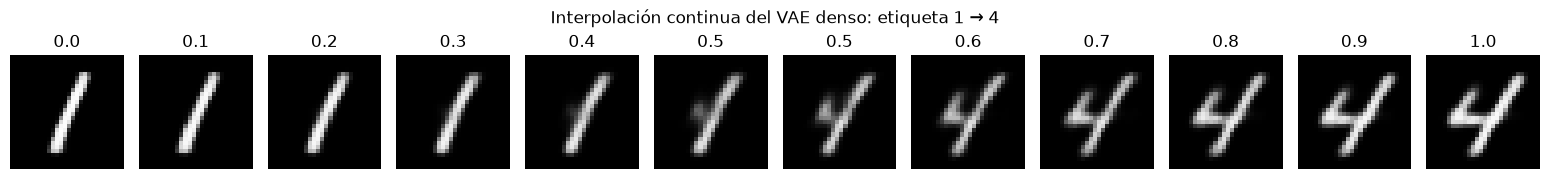

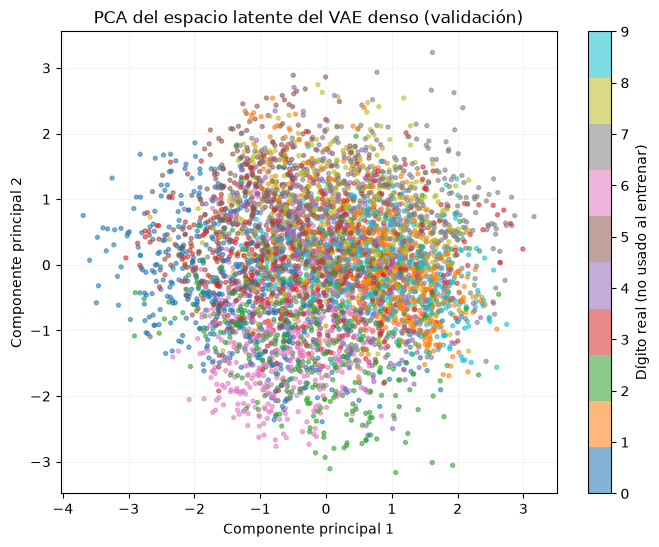

In [12]:
# Visualizamos reconstrucciones usando la media del posterior para evitar ruido de muestreo.
show_vae_reconstructions(
    dense_vae, val_loader, "VAE denso: reconstrucciones usando la media del posterior"
)
# Generamos ejemplos nuevos a partir de vectores muestreados del prior normal.
show_generated_samples(dense_vae, "VAE denso: muestras nuevas z ~ N(0, I)")
# Decodificamos puntos entre dos medias para observar continuidad en el espacio latente.
show_latent_interpolation(dense_vae, val_loader, "Interpolación continua del VAE denso")
# Proyectamos las medias latentes a dos dimensiones solo con fines interpretativos.
plot_latent_pca(dense_vae, val_loader, "PCA del espacio latente del VAE denso (validación)")

### Cómo interpretar estas figuras

1. **Reconstrucciones:** comprueban qué información atraviesa el cuello de botella. El VAE suele ser algo más borroso que el AE porque también debe satisfacer la KL.
2. **Muestras nuevas:** aquí no existe una imagen de entrada. Los vectores se obtienen de $\mathcal{N}(0,I)$ y demuestran la capacidad generativa.
3. **Interpolación:** una transición suave indica que regiones cercanas de $z$ producen salidas relacionadas. En un AE convencional, el segmento podría atravesar huecos sin significado.
4. **PCA:** `LATENT_DIM=16`, por lo que el gráfico no es el espacio completo, sino la proyección lineal que conserva la mayor varianza posible en dos ejes. El color procede de las etiquetas únicamente después de entrenar. Que existan solapamientos es normal: el objetivo era reconstruir, no separar clases.

El VAE denso todavía ignora una propiedad esencial: un píxel cercano suele estar más relacionado con sus vecinos que con uno situado al otro lado de la imagen. Al aplanar, esa estructura espacial deja de estar explícita.

## 13.6. Nivel 3: VAE convolucional

Una convolución aplica filtros locales compartidos por toda la imagen. Esto reduce parámetros, reconoce patrones independientemente de su posición y preserva mejor trazos y bordes. Usaremos `stride=2` para reducir alto y ancho, y convoluciones transpuestas para recuperarlos:

| Etapa | Operación | Forma sin el batch |
|---|---|---:|
| Entrada | Imagen | `1 × 28 × 28` |
| Encoder 1 | `Conv2d(1, 32, stride=2)` | `32 × 14 × 14` |
| Encoder 2 | `Conv2d(32, 64, stride=2)` | `64 × 7 × 7` |
| Posterior | Dos capas lineales | `mu, logvar: 16` |
| Proyección | Capa lineal y reshape | `64 × 7 × 7` |
| Decoder 1 | `ConvTranspose2d(64, 32)` | `32 × 14 × 14` |
| Decoder 2 | `ConvTranspose2d(32, 1)` | `1 × 28 × 28` |

Una convolución transpuesta es una operación aprendible de aumento espacial; no es la inversa matemática exacta de la convolución. No añadimos Batch Normalization para mantener limpia la interpretación de la distribución latente y evitar que las estadísticas del batch introduzcan otra fuente de variación.

In [13]:
# El ConvVAE conserva la estructura espacial de MNIST mediante filtros locales compartidos.
class ConvVAE(nn.Module):
    """VAE convolucional para MNIST con un posterior normal diagonal."""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # Guardamos la dimensión latente para construir y muestrear el espacio comprimido.
        self.latent_dim = latent_dim
        self.encoder_convolutions = nn.Sequential(
            # stride=2 reduce 28 x 28 a 14 x 14 y extrae 32 mapas de características.
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Una segunda reducción produce 64 mapas de 7 x 7 antes de las cabezas latentes.
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        # Este producto es el número de activaciones que conectaremos con mu y logvar.
        flattened_features = 64 * 7 * 7
        # Las dos cabezas estiman los parámetros del posterior normal diagonal.
        self.mu_head = nn.Linear(flattened_features, latent_dim)
        self.logvar_head = nn.Linear(flattened_features, latent_dim)
        # Proyectamos z de nuevo al volumen de características que alimenta al decoder.
        self.latent_projection = nn.Linear(latent_dim, flattened_features)
        self.decoder_convolutions = nn.Sequential(
            # La convolución transpuesta recupera 14 x 14 desde los mapas 7 x 7.
            nn.ConvTranspose2d(
                64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            # La segunda convolución transpuesta recupera la imagen de 28 x 28.
            nn.ConvTranspose2d(
                32, 1, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
        )

    def encode(self, images):
        # Las convoluciones extraen patrones locales sin perder la disposición espacial.
        feature_maps = self.encoder_convolutions(images)
        # Aplanamos solo al llegar a las cabezas lineales del posterior.
        flattened = feature_maps.flatten(start_dim=1)
        return self.mu_head(flattened), self.logvar_head(flattened)

    def reparameterize(self, mu, logvar):
        # Convertimos logvar en desviación estándar y añadimos ruido normal independiente.
        standard_deviation = torch.exp(0.5 * logvar)
        return mu + standard_deviation * torch.randn_like(standard_deviation)

    def decode(self, latent_vectors):
        # Transformamos cada vector latente en el volumen inicial del decoder.
        feature_maps = self.latent_projection(latent_vectors)
        # Recuperamos los canales y la cuadrícula 7 x 7 antes de aumentar resolución.
        feature_maps = feature_maps.view(-1, 64, 7, 7)
        return self.decoder_convolutions(feature_maps)

    def forward(self, images):
        # Encadenamos encoder, muestreo reparametrizado y decoder.
        mu, logvar = self.encode(images)
        latent_vectors = self.reparameterize(mu, logvar)
        return self.decode(latent_vectors), mu, logvar


# Instanciamos el ConvVAE en el dispositivo elegido.
conv_vae = ConvVAE().to(device)
# Comprobamos que las convoluciones preservan la forma esperada antes de entrenar.
with torch.no_grad():
    conv_logits, conv_mu, conv_logvar = conv_vae(sample_images[:4].to(device))

# Verificamos salida de imagen, dimensiones latentes y estabilidad numérica.
assert conv_logits.shape == sample_images[:4].shape
assert conv_mu.shape == conv_logvar.shape == (4, LATENT_DIM)
assert all(torch.isfinite(tensor).all() for tensor in (conv_logits, conv_mu, conv_logvar))
# Mostramos arquitectura, tamaño y formas observadas en el smoke test.
print(conv_vae)
print(f"Parámetros entrenables: {count_trainable_parameters(conv_vae):,}")
print(f"mu/logvar: {tuple(conv_mu.shape)} | reconstrucción: {tuple(conv_logits.shape)}")

ConvVAE(
  (encoder_convolutions): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (mu_head): Linear(in_features=3136, out_features=16, bias=True)
  (logvar_head): Linear(in_features=3136, out_features=16, bias=True)
  (latent_projection): Linear(in_features=16, out_features=3136, bias=True)
  (decoder_convolutions): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)
Parámetros entrenables: 191,265
mu/logvar: (4, 16) | reconstrucción: (4, 1, 28, 28)


ConvVAE | época 01/10 | beta: 0.25 | train rec/KL: 138.77/44.05 | val rec/KL/ELBO-: 97.46/38.75/136.21
ConvVAE | época 02/10 | beta: 0.50 | train rec/KL: 94.83/31.44 | val rec/KL/ELBO-: 91.31/31.24/122.55
ConvVAE | época 03/10 | beta: 0.75 | train rec/KL: 90.10/27.78 | val rec/KL/ELBO-: 87.17/29.03/116.20
ConvVAE | época 04/10 | beta: 1.00 | train rec/KL: 88.53/25.12 | val rec/KL/ELBO-: 87.21/25.13/112.34
ConvVAE | época 05/10 | beta: 1.00 | train rec/KL: 86.27/24.81 | val rec/KL/ELBO-: 86.35/24.39/110.74
ConvVAE | época 06/10 | beta: 1.00 | train rec/KL: 84.80/24.65 | val rec/KL/ELBO-: 84.25/24.78/109.03
ConvVAE | época 07/10 | beta: 1.00 | train rec/KL: 83.66/24.59 | val rec/KL/ELBO-: 83.70/24.60/108.30
ConvVAE | época 08/10 | beta: 1.00 | train rec/KL: 82.81/24.54 | val rec/KL/ELBO-: 82.74/24.62/107.36
ConvVAE | época 09/10 | beta: 1.00 | train rec/KL: 82.15/24.53 | val rec/KL/ELBO-: 82.20/24.33/106.54
ConvVAE | época 10/10 | beta: 1.00 | train rec/KL: 81.57/24.53 | val rec/KL/ELBO-

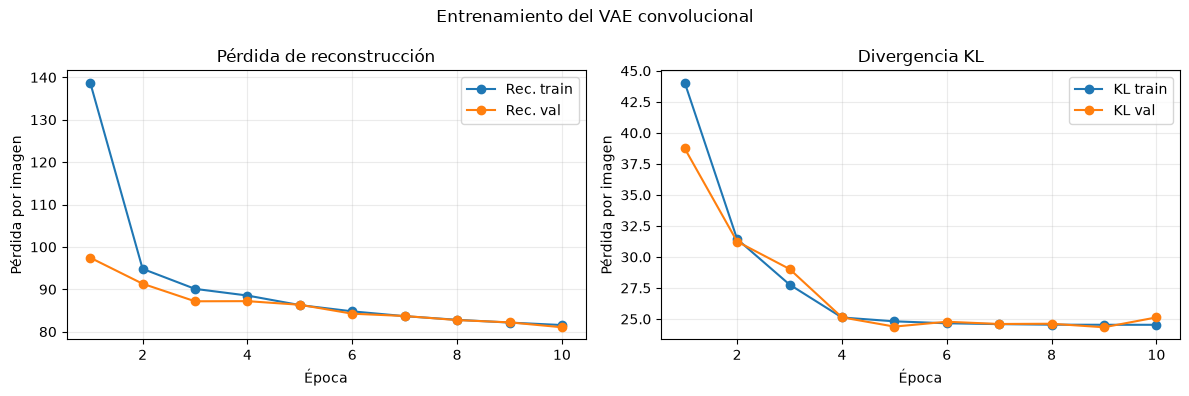

In [14]:
# Reutilizamos la misma prueba de pérdida para el ConvVAE antes de entrenarlo.
with torch.no_grad():
    conv_smoke_objective, _, conv_smoke_kl = vae_loss(
        conv_logits, sample_images[:4].to(device), conv_mu, conv_logvar
    )
# La pérdida debe ser finita y la KL debe respetar su no negatividad teórica.
assert torch.isfinite(conv_smoke_objective) and conv_smoke_kl >= 0

# El entrenador común aplica al ConvVAE el mismo warm-up y criterio de validación.
conv_vae_history = fit_vae(
    conv_vae, train_loader, val_loader, model_name="ConvVAE"
)
# Informamos el mejor objetivo de validación y el tiempo de entrenamiento.
print(f"Mejor ELBO negativa de validación: {conv_vae_history['best_val_loss']:.2f}")
print(f"Tiempo: {conv_vae_history['seconds']:.1f} s")
# Graficamos por separado fidelidad de reconstrucción y regularización KL.
plot_vae_history(conv_vae_history, "Entrenamiento del VAE convolucional")

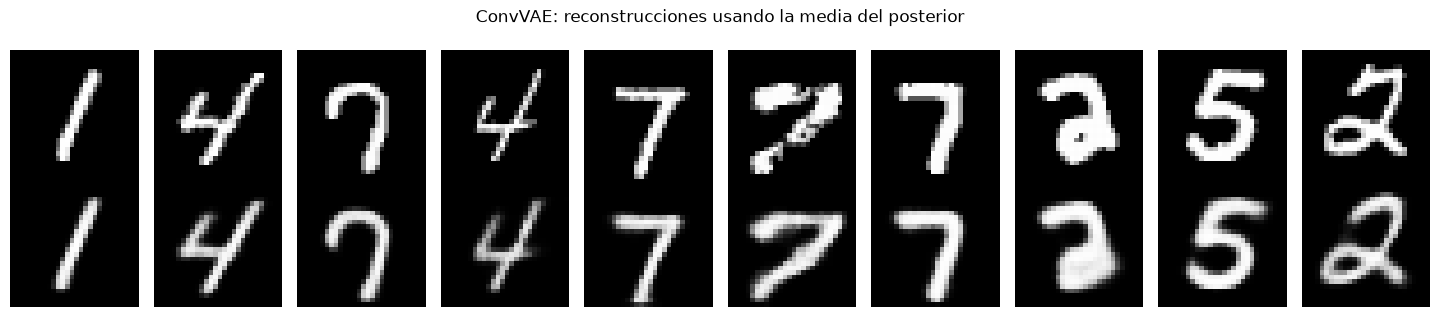

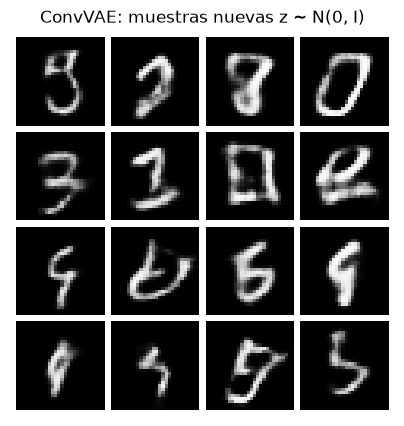

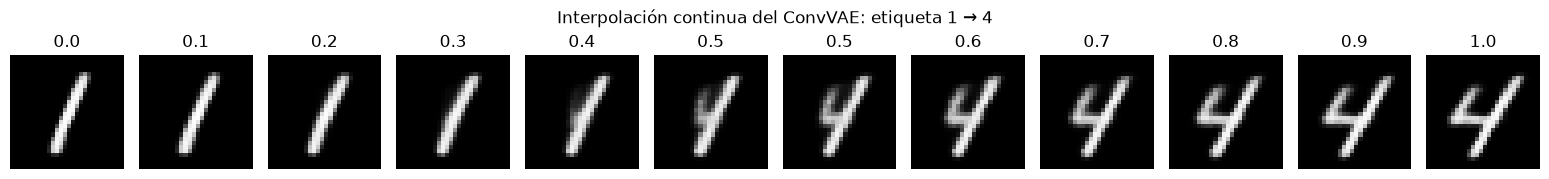

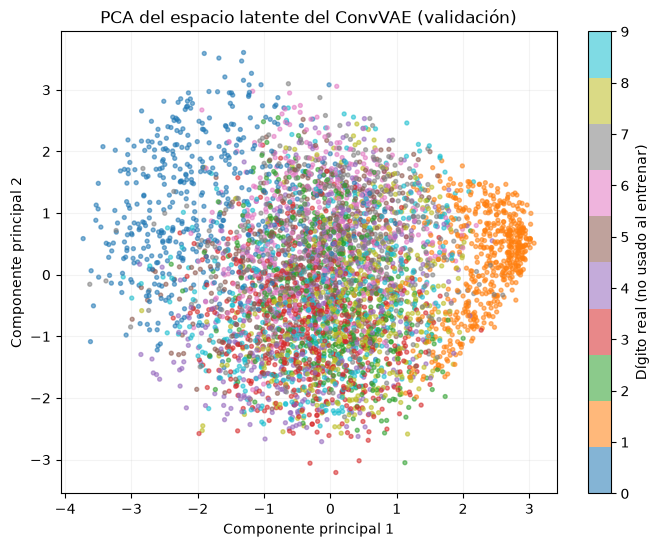

In [15]:
# Comparamos imágenes originales y reconstrucciones deterministas del ConvVAE.
show_vae_reconstructions(
    conv_vae, val_loader, "ConvVAE: reconstrucciones usando la media del posterior"
)
# Inspeccionamos imágenes nuevas generadas desde el prior normal.
show_generated_samples(conv_vae, "ConvVAE: muestras nuevas z ~ N(0, I)")
# Observamos cómo cambia la salida al recorrer el segmento entre dos puntos latentes.
show_latent_interpolation(conv_vae, val_loader, "Interpolación continua del ConvVAE")
# Proyectamos el espacio latente convolucional a dos dimensiones para interpretarlo.
plot_latent_pca(conv_vae, val_loader, "PCA del espacio latente del ConvVAE (validación)")

## Qué muestra el PCA

El gráfico PCA es un **mapa 2D aproximado del espacio latente de 16 dimensiones** del VAE.

No muestra píxeles, reconstrucciones ni probabilidades. Cada punto representa **una imagen de MNIST codificada por el encoder**.

```text
Una imagen
    ↓ encoder
mu = vector de 16 valores
    ↓ PCA
punto de 2 coordenadas (PC1, PC2)
```

La función está en `varitional_autoencoder.ipynb`.

## Qué representa cada punto

El código obtiene:

```python
mu, _ = model.encode(images.to(device))
latent_batches.append(mu.cpu())
```

Para cada imagen, el encoder genera:

$$
\mu=(\mu_1,\mu_2,\ldots,\mu_{16})
$$

Ese vector de 16 valores describe el centro de su distribución latente. Se utiliza `mu` y no una muestra aleatoria `z` para que el gráfico sea estable.

Por ejemplo:

```text
Imagen A → mu = [0.7, -1.2, 0.1, ..., 0.8]   (16 valores)
Imagen B → mu = [0.6, -1.0, 0.3, ..., 0.9]   (16 valores)
```

Cada vector es un punto en un espacio de 16 dimensiones, imposible de representar directamente en una pantalla.

## Qué hace PCA

PCA busca las direcciones del espacio latente en las que más varían los datos.

Primero centra los vectores:

```python
centered = latent - latent.mean(dim=0, keepdim=True)
```

A cada dimensión latente le resta su media:

$$
\tilde{\mu}_{n,j}=\mu_{n,j}-\overline{\mu}_j
$$

Después calcula las dos direcciones principales:

```python
_, _, principal_directions = torch.pca_lowrank(centered, q=2)
```

`principal_directions` tiene forma:

```text
(16, 2)
```

Sus columnas son:

- Primera componente principal, `PC1`.
- Segunda componente principal, `PC2`.

## Qué es una componente principal

Una componente principal **no es una de las 16 dimensiones latentes originales**. Es una combinación ponderada de todas ellas.

Por ejemplo, conceptualmente:

$$
PC1 =
0.3\mu_1-0.1\mu_2+0.5\mu_3+\cdots+0.2\mu_{16}
$$

$$
PC2 =
-0.2\mu_1+0.6\mu_2+0.1\mu_3+\cdots-0.4\mu_{16}
$$

Los coeficientes los calcula PCA automáticamente.

- `PC1` es la dirección que recoge la mayor variación posible.
- `PC2` recoge la siguiente mayor variación, siendo perpendicular a `PC1`.

No significa necesariamente que `PC1` sea “tipo de dígito” y `PC2` sea “grosor”. Pueden mezclar inclinación, forma, grosor y otros factores.

## La proyección

```python
projection = centered @ principal_directions[:, :2]
```

Las formas son:

```text
centered              (5000, 16)
principal_directions  (16, 2)
projection            (5000, 2)
```

Por tanto, cada vector de 16 dimensiones se convierte en dos coordenadas:

$$
(\mu_1,\ldots,\mu_{16})\longrightarrow(PC1,PC2)
$$

Esas coordenadas determinan la posición de cada punto en el gráfico:

```python
plt.scatter(
    projection[:, 0],  # eje horizontal: PC1
    projection[:, 1],  # eje vertical: PC2
    c=labels
)
```

## Cómo interpretarlo

- **Puntos cercanos:** el encoder produjo representaciones latentes parecidas.
- **Puntos alejados:** sus representaciones son diferentes.
- **Color:** etiqueta real del dígito, utilizada solo para interpretar el gráfico.
- **Grupos del mismo color:** el VAE ha aprendido características que distinguen indirectamente esos dígitos.
- **Colores solapados:** sus representaciones son parecidas o la separación existe en dimensiones descartadas por PCA.

Por ejemplo, un `3` y un `8` pueden aparecer cerca porque comparten trazos curvos.

## Qué información se pierde

PCA reduce:

$$
16\text{ dimensiones}\longrightarrow2\text{ dimensiones}
$$

Por tanto, el gráfico no muestra todo el espacio latente. Dos puntos pueden parecer juntos en 2D y estar separados en alguna de las otras 14 direcciones.

La idea esencial es:

> El PCA muestra dónde coloca el encoder cada imagen dentro del espacio latente, comprimido de 16 a 2 dimensiones para poder visualizarlo. Las componentes son direcciones estadísticas, no atributos con un significado fijo.

## 13.7. Evaluación final y comparación justa

Hasta este punto, entrenamiento actualizó los pesos y validación eligió el mejor estado. **Solo ahora** consultamos test. Esta separación estima mejor el rendimiento sobre datos no vistos.

No calculamos `accuracy`: el modelo no predice una clase. Las métricas adecuadas son:

- **Reconstrucción:** fidelidad de la imagen recuperada; menor es mejor.
- **KL:** coste de organizar el posterior cerca del prior. No buscamos simplemente minimizarla: una KL cercana a cero en todas las dimensiones puede indicar que el decoder ignora $z$.
- **Total del VAE:** reconstrucción + KL con $\beta=1$, es decir, la ELBO negativa estimada.

La ELBO se estima con una muestra de $z$ por imagen, por lo que puede variar ligeramente entre ejecuciones. Todas las pérdidas de la tabla son promedios **por imagen** y sumas sobre sus 784 píxeles. Esto evita que el último batch o el tamaño del dataset alteren la escala.

In [16]:
# Importamos las utilidades de IPython para presentar la comparación como tabla Markdown.
from IPython.display import Markdown, display

# Primera evaluación cuantitativa sobre el conjunto oficial de test.
# Test se consulta una sola vez, después de elegir modelos y pesos con validación.
ae_test_reconstruction = run_autoencoder_epoch(ae_model, test_loader)
dense_test_metrics = run_vae_epoch(dense_vae, test_loader, beta=1.0)
conv_test_metrics = run_vae_epoch(conv_vae, test_loader, beta=1.0)

# Unificamos métricas, coste y tamaño de los tres modelos para compararlos en una tabla.
comparison = [
    {
        "model": "AE denso",
        "parameters": count_trainable_parameters(ae_model),
        "epochs": AE_EPOCHS,
        "seconds": ae_history["seconds"],
        "reconstruction": ae_test_reconstruction,
        "kl": None,
        "total": ae_test_reconstruction,
    },
    {
        "model": "VAE denso",
        "parameters": count_trainable_parameters(dense_vae),
        "epochs": dense_vae_history["epochs_ran"],
        "seconds": dense_vae_history["seconds"],
        "reconstruction": dense_test_metrics["reconstruction"],
        "kl": dense_test_metrics["kl"],
        "total": dense_test_metrics["loss"],
    },
    {
        "model": "VAE convolucional",
        "parameters": count_trainable_parameters(conv_vae),
        "epochs": conv_vae_history["epochs_ran"],
        "seconds": conv_vae_history["seconds"],
        "reconstruction": conv_test_metrics["reconstruction"],
        "kl": conv_test_metrics["kl"],
        "total": conv_test_metrics["loss"],
    },
]

# Construimos manualmente las cabeceras para controlar el formato de la tabla resultante.
table_lines = [
    "| Modelo | Parámetros | Épocas | Tiempo (s) | Test reconstrucción | Test KL | Test total |",
    "|---|---:|---:|---:|---:|---:|---:|",
]
# Convertimos cada diccionario a una fila con dos decimales y una marca para el AE sin KL.
for result in comparison:
    kl_text = "No aplica" if result["kl"] is None else f"{result['kl']:.2f}"
    table_lines.append(
        f"| {result['model']} | {result['parameters']:,} | {result['epochs']} | "
        f"{result['seconds']:.1f} | {result['reconstruction']:.2f} | "
        f"{kl_text} | {result['total']:.2f} |"
    )

# Mostramos la comparación con el renderizador Markdown de Jupyter.
display(Markdown("\n".join(table_lines)))

# Identificamos por separado el menor error y el modelo más compacto.
best_reconstruction = min(comparison, key=lambda result: result["reconstruction"])
most_compact = min(comparison, key=lambda result: result["parameters"])
print(f"Menor error de reconstrucción en test: {best_reconstruction['model']}")
print(f"Modelo con menos parámetros: {most_compact['model']}")

| Modelo | Parámetros | Épocas | Tiempo (s) | Test reconstrucción | Test KL | Test total |
|---|---:|---:|---:|---:|---:|---:|
| AE denso | 410,912 | 5 | 11.3 | 79.57 | No aplica | 79.57 |
| VAE denso | 737,616 | 10 | 26.9 | 81.93 | 22.60 | 104.53 |
| VAE convolucional | 191,265 | 10 | 56.0 | 80.03 | 25.06 | 105.08 |

Menor error de reconstrucción en test: AE denso
Modelo con menos parámetros: VAE convolucional


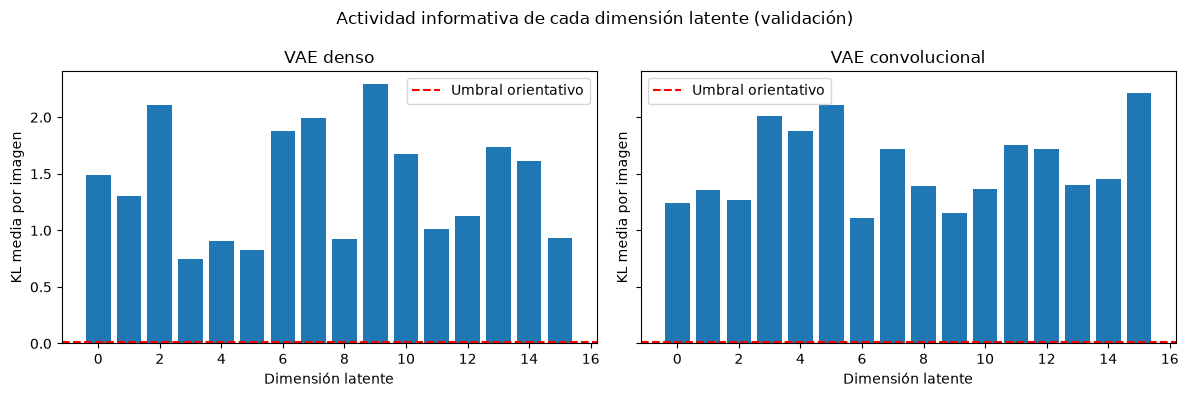

Dimensiones activas (KL > 0.01) | VAE denso: 16/16 | ConvVAE: 16/16


In [17]:
def mean_kl_per_latent_dimension(model, loader):
    """Calcula cuánta información aporta cada dimensión en validación."""
    # Evaluamos sin actualizar pesos porque solo queremos diagnosticar el espacio latente.
    model.eval()
    # Acumulamos una KL independiente para cada dimensión en CPU.
    kl_sum = torch.zeros(model.latent_dim)
    sample_count = 0
    with torch.no_grad():
        # Las etiquetas no son necesarias para calcular la actividad latente.
        for images, _ in loader:
            # El encoder devuelve los parámetros del posterior para cada imagen.
            mu, logvar = model.encode(images.to(device))
            # Aplicamos la fórmula de KL por muestra y por dimensión, sin sumar dimensiones todavía.
            kl_per_sample_and_dimension = -0.5 * (
                1 + logvar - mu.pow(2) - logvar.exp()
            )
            # Sumamos cada dimensión y trasladamos el resultado a CPU para el acumulador.
            kl_sum += kl_per_sample_and_dimension.sum(dim=0).cpu()
            sample_count += images.size(0)
    # Promediar por número de imágenes permite comparar datasets o batches de distinto tamaño.
    return kl_sum / sample_count


# Calculamos la actividad de cada dimensión en validación para ambos VAE.
dense_kl_by_dimension = mean_kl_per_latent_dimension(dense_vae, val_loader)
conv_kl_by_dimension = mean_kl_per_latent_dimension(conv_vae, val_loader)
# Este umbral es una alarma práctica, no una frontera matemática universal.
activity_threshold = 0.01

# Compartimos el eje Y para comparar directamente los dos modelos.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, values, name in (
    (axes[0], dense_kl_by_dimension, "VAE denso"),
    (axes[1], conv_kl_by_dimension, "VAE convolucional"),
):
    # Cada barra muestra la KL media que aporta una dimensión del espacio latente.
    axis.bar(np.arange(LATENT_DIM), values.numpy())
    # La línea facilita detectar dimensiones con actividad superior al umbral orientativo.
    axis.axhline(activity_threshold, color="red", linestyle="--", label="Umbral orientativo")
    axis.set_title(name)
    axis.set_xlabel("Dimensión latente")
    axis.set_ylabel("KL media por imagen")
    axis.legend()
plt.suptitle("Actividad informativa de cada dimensión latente (validación)")
plt.tight_layout()
plt.show()

# Contamos dimensiones activas para complementar la lectura de la KL global.
print(
    f"Dimensiones activas (KL > {activity_threshold}) | "
    f"VAE denso: {(dense_kl_by_dimension > activity_threshold).sum().item()}/{LATENT_DIM} | "
    f"ConvVAE: {(conv_kl_by_dimension > activity_threshold).sum().item()}/{LATENT_DIM}"
)

## 13.8. Interpretación de los resultados obtenidos

En esta ejecución se observan varias ideas importantes:

- El **AE denso** obtiene la reconstrucción más baja en test: `79.57`. Es esperable, porque toda su capacidad se dedica a copiar la entrada y no paga el coste de organizar el espacio latente.
- El **VAE denso** obtiene reconstrucción `81.94`, KL `22.60` y total `104.54`. Pierde algo de nitidez a cambio de poder muestrear e interpolar.
- El **VAE convolucional** mejora la reconstrucción del VAE denso hasta `80.05`, aunque su KL mayor (`25.06`) deja el total en `105.11`. Conserva más información local en $z$ y paga por alejar más su posterior del prior.
- El ConvVAE usa `191 265` parámetros frente a `737 616` del VAE denso. Compartir filtros reduce parámetros, pero las convoluciones pueden tardar más que matrices densas pequeñas; menos parámetros no implica automáticamente menos tiempo.
- Las `16/16` dimensiones superan el umbral orientativo de KL en ambos VAE. No se aprecia *posterior collapse*. El umbral `0.01` no es una ley matemática: sirve como alarma práctica y debe interpretarse junto con reconstrucciones, muestras y evolución de pérdidas.

No debemos comparar el `total` del AE con la ELBO negativa del VAE como si fueran el mismo objetivo: el AE no incluye KL. Tampoco tiene sentido exigir una accuracy superior al 95 %, porque aquí no se realiza clasificación. Una evaluación generativa más avanzada podría añadir FID, precisión/recobrado generativos o una evaluación humana, aunque FID es poco fiable con conjuntos tan simples y pequeños como MNIST.

| Propiedad | AE determinista | VAE denso | VAE convolucional |
|---|---|---|---|
| Salida del encoder | Un vector $z$ | $\mu$ y $\log\sigma^2$ | $\mu$ y $\log\sigma^2$ |
| Muestreo al entrenar | No | Sí | Sí |
| Regularización latente | No | KL con $\mathcal{N}(0,I)$ | KL con $\mathcal{N}(0,I)$ |
| Generación desde el prior | No fiable | Sí | Sí |
| Estructura espacial explícita | No | No | Sí |
| Ventaja principal | Reconstrucción sencilla | Fundamentos probabilísticos claros | Mejor inductive bias para imágenes |
| Limitación principal | Espacio con huecos | Ignora vecindades de píxeles | Mayor coste por época |

## 13.9. Qué sucede durante el entrenamiento

Cada batch atraviesa cinco pasos fundamentales:

1. `optimizer.zero_grad(set_to_none=True)` elimina los gradientes del batch anterior. PyTorch los acumula por defecto.
2. `model(images)` ejecuta encoder, reparametrización y decoder: es el **forward pass**.
3. `vae_loss(...)` calcula reconstrucción, KL y su suma ponderada.
4. `loss.backward()` aplica diferenciación automática y obtiene $\partial\mathcal{L}/\partial w$ para cada parámetro.
5. `optimizer.step()` actualiza los pesos con Adam.

Entrenar consiste, por tanto, en aproximar iterativamente:

$$
w_{t+1}=w_t-\eta\,\widehat{\nabla_w\mathcal{L}},
$$

donde $\eta$ es la tasa de aprendizaje y el gradiente del batch es una estimación del gradiente de todo el dataset.

### Modos de PyTorch

- `model.train()` activa el comportamiento de entrenamiento. En estos modelos afecta principalmente a la intención de uso; sería imprescindible con Dropout o BatchNorm.
- `model.eval()` selecciona el comportamiento de inferencia de esas capas.
- `torch.no_grad()` evita construir el grafo de gradientes, reduce memoria y acelera validación y visualización.
- `.to(device)` debe aplicarse tanto al modelo como a sus entradas. En PyTorch con AMD/ROCm el dispositivo sigue apareciendo como `cuda` por compatibilidad con la API.

### Early stopping y mejores pesos

El calentamiento modifica $\beta$ durante las primeras cuatro épocas. Comparar directamente objetivos con distintos $\beta$ sería engañoso, de modo que validación siempre calcula la ELBO con $\beta=1$ y el contador de early stopping comienza solo al terminar el calentamiento. `copy.deepcopy(model.state_dict())` conserva el mejor estado en memoria y se restaura al finalizar.

### BCE frente a MSE

| Pérdida | Interpretación frecuente | Efecto habitual |
|---|---|---|
| BCE | Cada píxel se modela como Bernoulli | Penaliza con fuerza probabilidades seguras y erróneas |
| MSE | Decoder gaussiano con varianza fija | Reconstrucciones suaves y escala distinta |

La elección depende del modelo probabilístico asumido. Cambiar BCE por MSE también cambia la escala relativa respecto a la KL, por lo que probablemente habrá que reajustar $\beta$; no basta con comparar números absolutos entre ambas pérdidas.

### Hiperparámetros principales

| Parámetro | Si disminuye | Si aumenta |
|---|---|---|
| `LATENT_DIM` | Mayor compresión, posible pérdida de detalle | Más capacidad, posibles dimensiones inactivas |
| `BATCH_SIZE` | Gradiente más ruidoso, menos memoria | Gradiente estable, más memoria y menos actualizaciones |
| `LEARNING_RATE` | Entrenamiento lento | Convergencia rápida o inestabilidad/NaN |
| $\beta$ | Mejores reconstrucciones, espacio irregular | Espacio regular, posible pérdida de información |
| Épocas | Posible infraajuste | Mejor convergencia o sobreajuste |

La dimensión latente 16 no es «la correcta» universal: es un compromiso didáctico. La selección rigurosa exige experimentar sobre validación y mantener test intacto.

## 13.10. Diagnóstico de problemas

| Síntoma | Causa probable | Comprobación y respuesta |
|---|---|---|
| `NaN` o infinito | Learning rate alto, `logvar` extremo | Bajar `LEARNING_RATE`; inspeccionar `mu`, `logvar` y gradientes |
| Error de dispositivos | Modelo en GPU y tensor en CPU, o al revés | Revisar `.to(device)` y usar `randn_like` |
| Forma distinta de `28×28` | Parámetros de convolución transpuesta | Verificar `stride`, `padding` y `output_padding` con el assert |
| KL casi cero desde el inicio | Posterior collapse | Calentar $\beta$, reducir capacidad del decoder o usar *free bits* |
| KL domina la pérdida | Regularización demasiado fuerte | Reducir $\beta$ o alargar su calentamiento |
| Reconstrucción buena, muestras malas | Espacio latente irregular | Aumentar regularización y comprobar muestras desde el prior |
| Train mejora y validación empeora | Sobreajuste | Early stopping, menos capacidad o más datos |
| Salidas completamente negras/blancas | Sigmoide duplicada o rango incorrecto | Mantener logits y comprobar que las entradas están en $[0,1]$ |

Una KL global razonable puede ocultar dimensiones inactivas. Por eso se ha dibujado la KL por dimensión. Otra técnica, llamada **free bits**, permite que cada dimensión aporte una pequeña KL antes de penalizarla, favoreciendo el uso del espacio latente.

Las imágenes generadas pueden ser borrosas porque BCE favorece promedios cuando varias salidas son plausibles. Los VAE priorizan cobertura y continuidad probabilística, no nitidez máxima. Modelos posteriores como VQ-VAE, flujos normalizantes y modelos de difusión atacan distintas limitaciones de este compromiso.

### Reproducibilidad

Se fijan las semillas de Python, NumPy y PyTorch, y tanto la partición como el barajado tienen generadores explícitos. Aun así, operaciones paralelas de GPU, versiones de librerías y hardware pueden producir pequeñas diferencias. Debe esperarse reproducibilidad aproximada de curvas y conclusiones, no necesariamente igualdad bit a bit.

## 13.11. Experimentos guiados

Estos experimentos reutilizan el código anterior. Para mantener comparaciones válidas, debe cambiarse **una variable cada vez**, reinicializar el modelo y conservar las mismas particiones.

1. **Capacidad latente:** probar `LATENT_DIM = 2, 8, 32`. Registrar reconstrucción, KL, dimensiones activas y calidad de muestras. Con dos dimensiones se puede dibujar $z$ directamente, pero se pierde detalle; con 32 pueden aparecer dimensiones sin uso.
2. **Sin calentamiento:** establecer `BETA_WARMUP_EPOCHS = 1`. Observar si la KL cae pronto y si las reconstrucciones empeoran. Esto permite medir la utilidad real del *warm-up*.
3. **$\beta$-VAE:** hacer que el entrenamiento alcance $\beta=2$ o $4$. Se espera más presión hacia el prior y, potencialmente, factores más separados, pero MNIST no garantiza *disentanglement* sin supervisión.
4. **BCE frente a MSE:** sustituir la reconstrucción por `F.mse_loss(..., reduction="sum")`. La salida puede seguir siendo logits solo si se aplica sigmoide antes de MSE. Comparar visualmente, no mediante los números brutos de pérdidas con escalas diferentes.
5. **Ablación de la KL:** entrenar con $\beta=0$. Las reconstrucciones probablemente mejorarán, pero las muestras desde $\mathcal{N}(0,I)$ deberían degradarse. Es la diferencia experimental más directa entre AE y VAE.
6. **Interpolación fuera de distribución:** multiplicar vectores del prior por 2 o 3. Cuanto más lejos estén de la masa típica de $\mathcal{N}(0,I)$, menos plausibles serán las imágenes.
7. **Más profundidad:** añadir un bloque convolucional, comprobando todas las formas. Mayor capacidad no garantiza una ELBO mejor y aumenta el riesgo de que el decoder ignore $z$.
8. **Conditional VAE (CVAE):** concatenar una codificación one-hot de la etiqueta al encoder y al decoder. Entonces el modelo aprende $p(x\mid z,y)$ y permite pedir explícitamente un dígito concreto. A diferencia de este VAE, ya sería aprendizaje condicionado por etiquetas.

### Preguntas de autoevaluación

- ¿Por qué muestrear directamente con `torch.normal(mu, sigma)` dificulta explicar la retropropagación?
- ¿Por qué una KL de cero no representa necesariamente el mejor modelo?
- ¿Por qué el AE puede reconstruir mejor y, aun así, ser peor generador?
- ¿Qué diferencia existe entre usar `mu` para reconstruir y muestrear $z$ durante el entrenamiento?
- ¿Por qué no debe utilizarse test para elegir dimensión latente, $\beta$ o número de épocas?
- ¿Qué información se pierde al representar 16 dimensiones mediante PCA en dos ejes?

## 13.12. Conclusión

El recorrido ha evolucionado desde una compresión determinista hasta dos modelos generativos:

1. El AE establece el mecanismo encoder-cuello de botella-decoder y optimiza únicamente reconstrucción.
2. El VAE denso convierte cada entrada en una distribución, hace diferenciable el muestreo mediante reparametrización y estructura el espacio con KL.
3. El ConvVAE incorpora el conocimiento de que una imagen posee estructura local y logra reconstrucciones competitivas con muchos menos parámetros.

La idea esencial es el equilibrio entre **fidelidad** y **regularidad probabilística**. La reconstrucción preserva cada ejemplo; la KL hace que podamos recorrer y muestrear el espacio latente. Ninguna métrica aislada resume ese equilibrio: hay que leer conjuntamente pérdidas, muestras, interpolaciones, actividad de las dimensiones y comportamiento sobre validación/test.